In [10]:
import os
import sys
import torch
import string
from PIL import Image
from huggingface_hub import HfApi, login
from transformers import AutoModel, AutoProcessor, pipeline

sys.path.append(os.path.abspath(os.path.join("..")))
from deploy.captcha_convolutionaltransformer_finetuned.configuration_captcha import CaptchaConfig
from deploy.captcha_convolutionaltransformer_finetuned.processing_captcha import CaptchaProcessor
from deploy.captcha_convolutionaltransformer_finetuned.modeling_captcha import CaptchaConvolutionalTransformer
from src.models.convoluationaltransformer.convtrans_v1 import Captcha_Convolutional_Transformer_V1

# Deploy Captcha-ConvolutionalTransformer-Finetuned

In [2]:
# Load your old weights
old_weights = torch.load(Captcha_Convolutional_Transformer_V1.SAVE_DIR / "v6.pth", map_location="cpu")

# Initialize the new HF-style model
config = CaptchaConfig()
hf_model = CaptchaConvolutionalTransformer(config)

# Load the weights into the HF-style model
hf_model.load_state_dict(old_weights)

# Save locally as a standard HF repo
hf_model.save_pretrained("../deploy/captcha_convolutionaltransformer_finetuned")

/nfs/home/tpz8688/Captcha-Recognition/deploy/captcha_convolutionaltransformer_finetuned/modeling_captcha.py:66: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [3]:
# Create the processor with your specific vocab
vocab = string.ascii_lowercase + string.ascii_uppercase + string.digits
processor = CaptchaProcessor(vocab=vocab)

# Save it into the SAME folder as your model
processor.save_pretrained("../deploy/captcha_convolutionaltransformer_finetuned")

['../deploy/captcha_convolutionaltransformer_finetuned/processor_config.json']

### Manually add to config.json

```
"auto_map": {
    "AutoConfig": "configuration_captcha.CaptchaConfig",
    "AutoModel": "modeling_captcha.CaptchaConvolutionalTransformer",
    "AutoProcessor": "processing_captcha.CaptchaProcessor"
  }
```

### Manually add to processor_config.json

```
"auto_map": {
    "AutoProcessor": "processing_captcha.CaptchaProcessor"
  }
```

### Manually add to config.json

```
"custom_pipelines": {
    "captcha-recognition": {
      "impl": "pipeline.CaptchaPipeline",
      "pt": ["AutoModel"],
      "type": "multimodal"
    }
  }
```

### Upload to HuggingFace

In [11]:
api = HfApi()
# login(token="***")

# 1. Create the repository
repo_id = "Graf-J/captcha-conv-transformer-finetuned"
api.create_repo(repo_id=repo_id, exist_ok=True)

# 2. Upload everything
api.upload_folder(
    folder_path="../deploy/captcha_convolutionaltransformer_finetuned",
    repo_id=repo_id,
    commit_message="Add Comparison-Table to Readme"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned/commit/0c36de8a0c57be00089b27aa766445e4177120af', commit_message='Add Comparison-Table to Readme', commit_description='', oid='0c36de8a0c57be00089b27aa766445e4177120af', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned', endpoint='https://huggingface.co', repo_type='model', repo_id='Graf-J/captcha-conv-transformer-finetuned'), pr_revision=None, pr_num=None)

### Test Code

In [5]:
from transformers import pipeline
from PIL import Image

# Initialize the pipeline
pipe = pipeline(
    task="captcha-recognition", 
    model="Graf-J/captcha-conv-transformer-finetuned", 
    trust_remote_code=True
)

# Load and predict
img = Image.open("Vb4cG.jpg")
result = pipe(img)
print(f"Decoded Text: {result['prediction']}")


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

configuration_captcha.py:   0%|          | 0.00/568 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- configuration_captcha.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pipeline.py:   0%|          | 0.00/561 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- pipeline.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

Loading weights:   0%|          | 0/43 [00:00<?, ?it/s]

processor_config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

processing_captcha.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- processing_captcha.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Decoded Text: Vb4cG


In [7]:
import torch
from PIL import Image
from transformers import AutoModel, AutoProcessor

# Load Model & Custom Processor
repo_id = "Graf-J/captcha-conv-transformer-finetuned"
processor = AutoProcessor.from_pretrained(repo_id, trust_remote_code=True)
model = AutoModel.from_pretrained(repo_id, trust_remote_code=True)

model.eval()

# Load and process image
img = Image.open("Vb4cG.jpg")
inputs = processor(img) 

# Inference
with torch.no_grad():
    outputs = model(inputs["pixel_values"])
    logits = outputs.logits

# Decode the prediction via CTC logic
prediction = processor.batch_decode(logits)[0]
print(f"Prediction: '{prediction}'")


A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- processing_captcha.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- configuration_captcha.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- modeling_captcha.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/nfs/home/tpz8688/.cache/huggingface/modules/transformers_modules/Graf_hyphen_J/captcha_hyphen_conv_hyphen_t

Loading weights:   0%|          | 0/43 [00:00<?, ?it/s]

Prediction: 'Vb4cG'


A new version of the following files was downloaded from https://huggingface.co/Graf-J/captcha-conv-transformer-finetuned:
- pipeline.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/nfs/home/tpz8688/.cache/huggingface/modules/transformers_modules/Graf_hyphen_J/captcha_hyphen_conv_hyphen_transformer_hyphen_finetuned/d2d0d7ca6d9f2fcd9effb08b4c9eed717fa21638/modeling_captcha.py:66: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Loading weights:   0%|          | 0/43 [00:00<?, ?it/s]

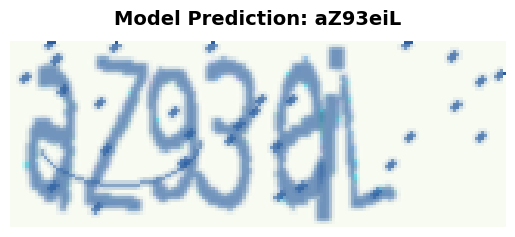

In [8]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
from captcha.image import ImageCaptcha

# Define CAPTCHA text to be generated (a-z A-Z 0-9 and length between 1 and 8)
captcha_text = "aZ93eiL"
assert captcha_text.isalnum() and 1 <= len(captcha_text) <= 8

# Generate CAPTCHA image
generator = ImageCaptcha(fonts=["../data/Nunito.ttf"])
image_data = generator.generate(captcha_text)
image = Image.open(image_data)

# Initialize the pipeline
pipe = pipeline(
    task="captcha-recognition",
    model="Graf-J/captcha-conv-transformer-finetuned",
    trust_remote_code=True
)

# Predict
result = pipe(image)["prediction"]

# Display result
plt.imshow(image)
plt.title(f"Model Prediction: {result}", fontsize=14, fontweight='bold', pad=12)
plt.axis('off')
plt.show()
